# Đồ án 2: Data Fitting và Phương pháp OLS
## Phần 1: Lý thuyết Data Fitting và Minh họa

---

### 1. Ordinary Least Squares (OLS) 

#### 1.1. Công thức toán học
Mô hình hồi quy tuyến tính: $y = X\beta + \varepsilon$

- Nghiệm OLS (Normal Equations): $\hat{\beta}_{OLS} = (X^T X)^{-1} X^T y$
- Ma trận chiếu (Hat Matrix): $H = X(X^T X)^{-1} X^T$
- Ước lượng phương sai nhiễu ($\hat{\sigma}^2$): $\hat{\sigma}^2 = \frac{RSS}{n - (p+1)}$ (Trong đó $n$ là số quan sát, $p$ là số biến độc lập không tính intercept).
---

In [1]:
import math
import random
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
import scipy.stats as stats
from sklearn.linear_model import LinearRegression
from ols_implementation import manual_transpose, manual_matmul, manual_solve, manual_inv, ols_fit, hat_matrix, model_metrics, coef_inference, vif, run_monte_carlo
from ridge_lasso import ridge_fit, ridge_trace
from residual_analysis import get_residuals, get_standardized_residuals, cook_distance 
from cross_validation import kfold_cv

In [2]:
# 1. Sinh dữ liệu giả lập
random.seed(42)
n, p = 100, 3
X = []
for _ in range(n):
    row = [1.0] + [random.gauss(0, 1) for _ in range(p)]
    X.append(row)
true_beta = [2.5, 1.5, -2.0, 3.0]

y = []
for i in range(n):
    # Tính X_i * beta
    xi_beta = sum(X[i][j] * true_beta[j] for j in range(len(true_beta)))
    noise = random.gauss(0, 1.0)
    y.append(xi_beta + noise)

# 2. Cài đặt từ đầu
beta_hat, sigma2_hat = ols_fit(X, y)
# Chuyển beta_hat về array chỉ để in ra cho đẹp (làm tròn số)
print("Hệ số beta ước lượng:", [round(b, 4) for b in beta_hat])
print("Ước lượng sigma^2:", round(sigma2_hat, 4))

# 3. Kiểm chứng với Scikit-learn
model = LinearRegression(fit_intercept=False).fit(X, y)
print("Hệ số beta (Sklearn):     ", model.coef_.round(4))
diff = sum((beta_hat[i] - model.coef_[i])**2 for i in range(len(beta_hat)))
if diff < 1e-10:
    print("\nKẾT QUẢ KHỚP HOÀN TOÀN VỚI SKLEARN!")

Hệ số beta ước lượng: [2.5913, 1.4953, -2.2653, 2.8985]
Ước lượng sigma^2: 0.9646
Hệ số beta (Sklearn):      [ 2.5913  1.4953 -2.2653  2.8985]

KẾT QUẢ KHỚP HOÀN TOÀN VỚI SKLEARN!


### 2. Ma trận chiếu (Hat Matrix)

Tính chất của $H$:
1. Idempotent: $H^2 = H$
2. Đối xứng: $H^T = H$
3. $rank(H) = p + 1$

In [3]:
# Tính toán ma trận Hat
X_input = X.tolist() if hasattr(X, "tolist") else X
H = hat_matrix(X_input)

# Kiểm tra tính đối xứng H^T = H
Ht = manual_transpose(H)
is_symmetric = True
for i in range(len(H)):
    for j in range(len(H[0])):
        if abs(H[i][j] - Ht[i][j]) > 1e-10:
            is_symmetric = False
            break
    if not is_symmetric: break

# 1. Kiểm tra tính Idempotent: H * H = H
H2 = manual_matmul(H, H)
is_idempotent = True
for i in range(len(H)):
    for j in range(len(H[0])):
        if abs(H[i][j] - H2[i][j]) > 1e-10:
            is_idempotent = False
            break
    if not is_idempotent: break

trace_H = sum(H[i][i] for i in range(len(H)))
print(f"Tính Đối xứng (H^T = H): {is_symmetric}")
print(f"Tính Idempotent (H^2 = H): {is_idempotent}")
print(f"Trace của H (Rank): {round(trace_H, 4)}")
if round(trace_H) == (p + 1):
    print(f"Rank khớp với lý thuyết: {p + 1}")


Tính Đối xứng (H^T = H): True
Tính Idempotent (H^2 = H): True
Trace của H (Rank): 4.0
Rank khớp với lý thuyết: 4


### 3. Đánh giá mô hình và Kiểm định thống kê

- RSS (Residual Sum of Squares): $\sum (y_i - \hat{y}_i)^2$
- $R^2$: Hệ số xác định.
- Adjusted $R^2$: Phạt khi thêm nhiều biến.
- F-test: Kiểm định ý nghĩa toàn bộ mô hình.
- t-test: Kiểm định ý nghĩa từng hệ số $\beta_j$.

In [4]:
# Tính y_hat
y_hat = manual_matmul(X, beta_hat)
rss, tss, r2, r2_adj, f_stat, f_pvalue = model_metrics(y, y_hat, p)

print(f"Residual Sum of Squares (RSS): {rss:.4f}")
print(f"R-squared: {r2:.4f}")
print(f"Adj R-squared: {r2_adj:.4f}")
print(f"F-statistic: {f_stat:.4f} (p-value: {f_pvalue:.4e})")

# Suy diễn thống kê cho hệ số
se, t_stat, p_values, ci = coef_inference(X, y, beta_hat, sigma2_hat)

# Tạo bảng tổng hợp bằng Pandas
inference_df = pd.DataFrame({
    'Variable': [f'X{i}' if i > 0 else 'Intercept' for i in range(len(beta_hat))],
    'Beta_Hat': beta_hat,
    'Std_Error': se,
    't_stat': t_stat,
    'p_value': p_values,
    'CI_Lower': ci[0],
    'CI_Upper': ci[1]
})

print("\nThống kê suy diễn hệ số:")
display(inference_df.round(4))


Residual Sum of Squares (RSS): 92.6055
R-squared: 0.9480
Adj R-squared: 0.9464
F-statistic: 583.3028 (p-value: 0.0000e+00)

Thống kê suy diễn hệ số:


,Variable,Beta_Hat,Std_Error,t_stat,p_value,CI_Lower,CI_Upper
0,Intercept,2.5913,0.0995,26.0400,0.0,2.3937,2.7888
1,X1,1.4953,0.1106,13.5251,0.0,1.2758,1.7147
2,X2,-2.2653,0.0976,-23.2004,0.0,-2.4591,-2.0714
3,X3,2.8985,0.0906,31.9745,0.0,2.7185,3.0784


### 4. Đa cộng tuyến (VIF)

VIF (Variance Inflation Factor) giúp phát hiện sự phụ thuộc tuyến tính giữa các biến độc lập.
$VIF_j = \frac{1}{1 - R_j^2}$

In [5]:
# Tính toán VIF cho các biến (loại trừ biến Intercept)
vif_vals = vif(X)

print("=== Kết quả Variance Inflation Factor (VIF) ===")
for i, val in enumerate(vif_vals):
    print(f"  VIF(X{i+1}) = {val:.4f}")

=== Kết quả Variance Inflation Factor (VIF) ===
  VIF(X1) = 1.0037
  VIF(X2) = 1.0020
  VIF(X3) = 1.0051


### 5. Ridge và Lasso Regression

Phương pháp hồi quy Ridge giải quyết bài toán đa cộng tuyến và overfitting bằng cách thêm thành phần phạt $L_2$ vào hàm mất mát:
- Nghiệm Ridge: $\hat{\beta}_{Ridge} = (X^T X + \lambda I)^{-1} X^T y$  
- Ridge Trace: Biểu đồ thể hiện sự thay đổi của các hệ số $\beta$ theo tham số điều chuẩn $\lambda$.

<>:12: SyntaxWarning: invalid escape sequence '\l'
<>:13: SyntaxWarning: invalid escape sequence '\h'
<>:12: SyntaxWarning: invalid escape sequence '\l'
<>:13: SyntaxWarning: invalid escape sequence '\h'
/tmp/ipykernel_15791/2205704876.py:12: SyntaxWarning: invalid escape sequence '\l'
  plt.xlabel('Lambda ($\lambda$)')
/tmp/ipykernel_15791/2205704876.py:13: SyntaxWarning: invalid escape sequence '\h'
  plt.ylabel('Coefficients ($\hat{\\beta}$)')


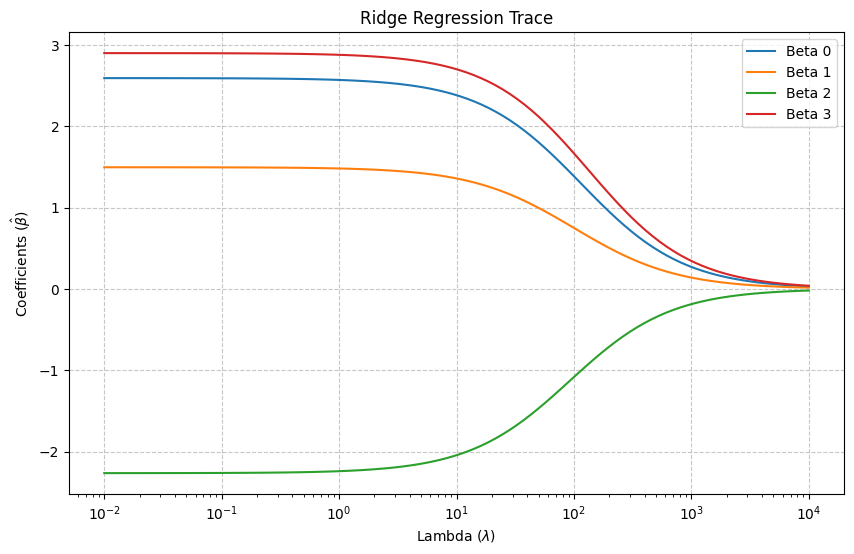

In [6]:
lam_list = [10**( -2 + (4 - (-2)) * i / 99 ) for i in range(100)]
# traces trả về danh sách các kết quả beta cho từng lambda
traces = ridge_trace(X, y, lam_list)
traces_T = manual_transpose(traces)


plt.figure(figsize=(10, 6))
for i in range(len(traces_T)):
    plt.plot(lam_list, traces_T[i], label=f'Beta {i}')

plt.xscale('log')
plt.xlabel('Lambda ($\lambda$)')
plt.ylabel('Coefficients ($\hat{\\beta}$)')
plt.title('Ridge Regression Trace')
plt.legend([f'Beta {i}' for i in range(len(traces[0]))])
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()


### 6. Phân tích phần dư (Residual Analysis)

Sử dụng 4 biểu đồ để kiểm tra các giả thiết Gauss-Markov.
1. Residuals vs Fitted: Tuyến tính và đồng phương sai.
2. Normal Q-Q: Tính chuẩn của sai số.
3. Scale-Location: Kiểm tra đồng phương sai.
4. Cook's Distance: Xác định điểm ảnh hưởng lớn.

<>:29: SyntaxWarning: invalid escape sequence '\s'
<>:29: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_15791/251791029.py:29: SyntaxWarning: invalid escape sequence '\s'
  axs[1, 0].set_ylabel('$\sqrt{|Standardized Residuals|}$')


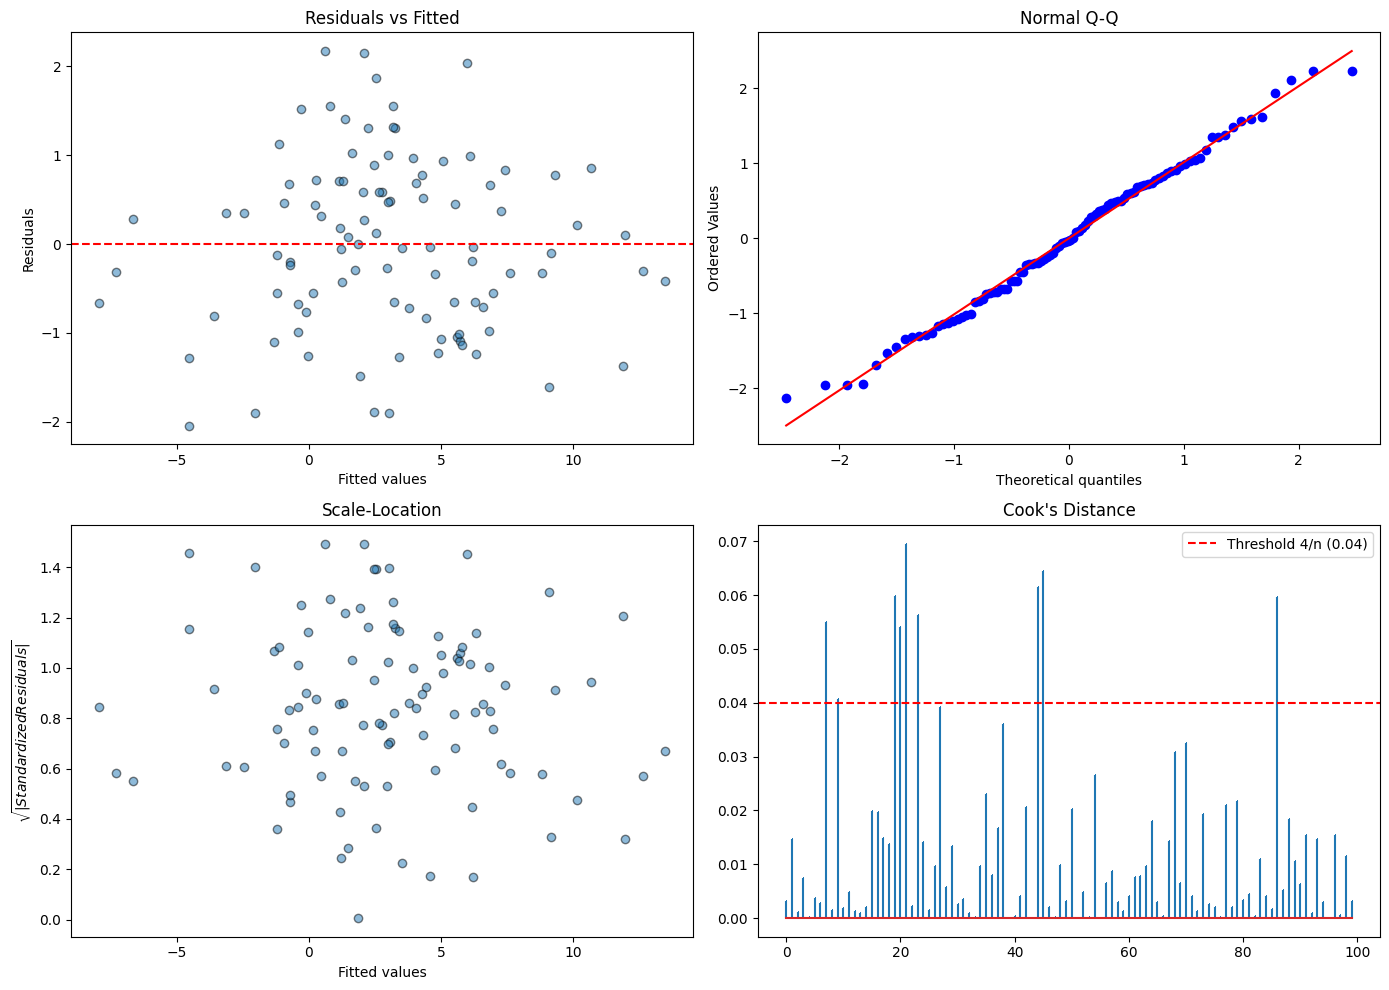

In [7]:
# 1. Gọi các hàm tính toán 
residuals = get_residuals(X, y, beta_hat)
std_residuals, h_ii = get_standardized_residuals(X, residuals, sigma2_hat)
cooks_d = cook_distance(std_residuals, h_ii, p)

# 2. Tính y_hat để làm trục hoành (Fitted values)
y_hat = manual_matmul(X, beta_hat)

sqrt_abs_std_resid = [math.sqrt(abs(r)) for r in std_residuals]

# 3. Vẽ 4 biểu đồ chẩn đoán mô hình
fig, axs = plt.subplots(2, 2, figsize=(14, 10))

# Biểu đồ 1: Residuals vs Fitted (Kiểm tra tính tuyến tính và phương sai nhiễu)
axs[0, 0].scatter(y_hat, residuals, alpha=0.5, edgecolors='k')
axs[0, 0].axhline(0, color='red', linestyle='--')
axs[0, 0].set_title('Residuals vs Fitted')
axs[0, 0].set_xlabel('Fitted values')
axs[0, 0].set_ylabel('Residuals')

# Biểu đồ 2: Normal Q-Q (Kiểm tra phân phối chuẩn của sai số)
stats.probplot(std_residuals, dist="norm", plot=axs[0, 1])
axs[0, 1].set_title('Normal Q-Q')

# Biểu đồ 3: Scale-Location (Kiểm tra tính đồng nhất của phương sai)
axs[1, 0].scatter(y_hat, sqrt_abs_std_resid, alpha=0.5, edgecolors='k')
axs[1, 0].set_title('Scale-Location')
axs[1, 0].set_xlabel('Fitted values')
axs[1, 0].set_ylabel('$\sqrt{|Standardized Residuals|}$')

# Biểu đồ 4: Cook\'s Distance (Phát hiện các điểm có ảnh hưởng lớn/Outliers)
axs[1, 1].stem(list(range(len(cooks_d))), cooks_d, markerfmt=",")
axs[1, 1].axhline(4/len(y), color='red', linestyle='--', label=f'Threshold 4/n ({round(4/len(y),3)})')
axs[1, 1].set_title("Cook's Distance")
axs[1, 1].legend()

plt.tight_layout()
plt.show()


### 7. K-Fold Cross Validation

Đánh giá độ ổn định của mô hình trên dữ liệu chưa biết.

=== Kết quả 5-Fold Cross Validation (Tự cài đặt) ===
  Mean MSE: 1.048318
  MSE từng fold: [1.353178, 0.738128, 1.223039, 1.138824, 0.788421]


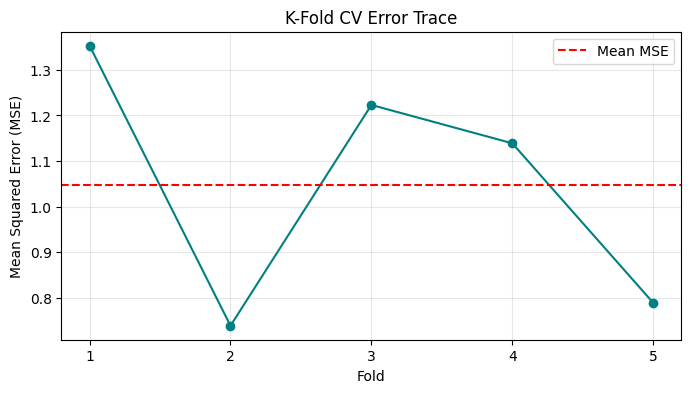

In [11]:
# Thực hiện k-Fold CV (kết quả trả về là trung bình MSE và danh sách MSE từng fold)
cv_score, mse_list = kfold_cv(X, y, k=5)

print(f"=== Kết quả 5-Fold Cross Validation (Tự cài đặt) ===")
print(f"  Mean MSE: {cv_score:.6f}")
print(f"  MSE từng fold: {[round(m, 6) for m in mse_list]}")

# Vẽ biểu đồ MSE qua các fold để trực quan hóa
plt.figure(figsize=(8, 4))
plt.plot(range(1, 6), mse_list, marker='o', linestyle='-', color='teal')
plt.axhline(cv_score, color='red', linestyle='--', label='Mean MSE')
plt.xlabel('Fold')
plt.ylabel('Mean Squared Error (MSE)')
plt.title('K-Fold CV Error Trace')
plt.xticks(range(1, 6))
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


### 8. Minh họa định lý Gauss-Markov (Monte Carlo Simulation)

Sử dụng mô phỏng Monte Carlo để thực nghiệm kiểm chứng tính chất BLUE (Best Linear Unbiased Estimator):

1. Tính không chệch: $E[\hat{\beta}] = \beta$
2. Hiệu quả: OLS có phương sai nhỏ nhất trong lớp các ước lượng tuyến tính không chệch.


=== Kết quả mô phỏng Monte Carlo (1000 iterations) ===
True Beta:  [2.5, 1.5, -2.0, 3.0]
Mean Beta (từ mô phỏng): [2.5019, 1.5014, -2.0036, 3.0029]

So sánh sai số (Bias): [0.001902, 0.001397, -0.003604, 0.002891]


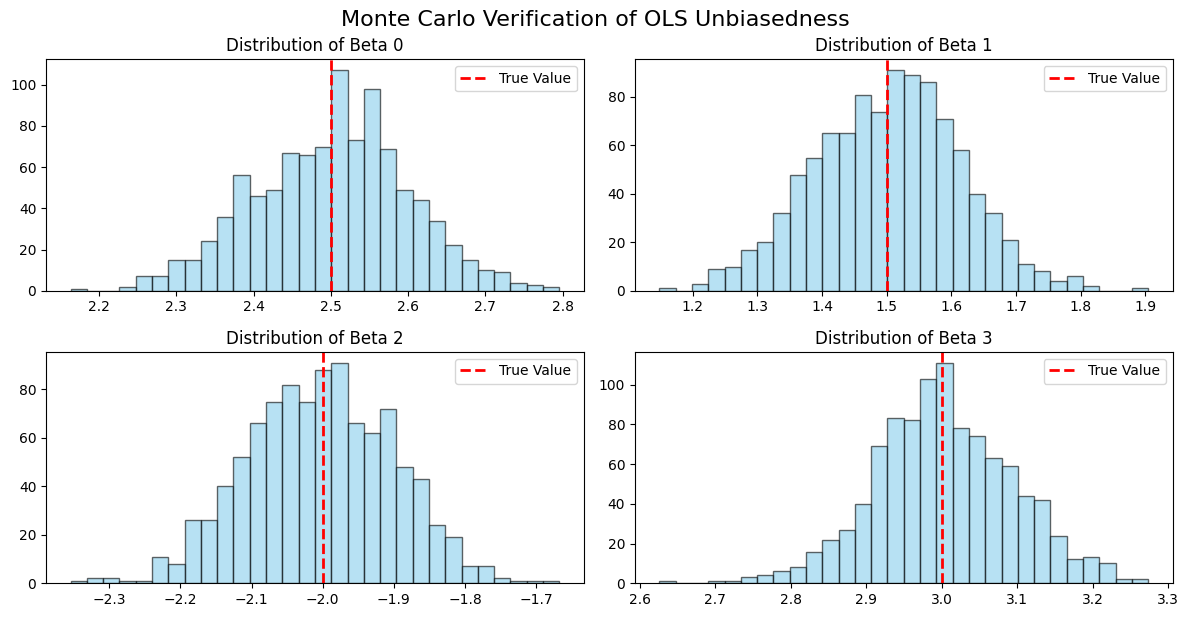

In [12]:
# Thực hiện mô phỏng Monte Carlo (1000 lần)
# true_beta đã được khai báo ở Cell 1 là: np.array([2.5, 1.5, -2.0, 3.0])
ols_betas = run_monte_carlo(X, true_beta, sigma=1.0, n_sims=1000)

# Chuyển về numpy để tính thống kê và vẽ hình
mean_betas = [sum(col) / len(col) for col in zip(*ols_betas)]
bias = [mean_betas[j] - true_beta[j] for j in range(len(true_beta))]

print("=== Kết quả mô phỏng Monte Carlo (1000 iterations) ===")
print("True Beta: ", true_beta)
print("Mean Beta (từ mô phỏng):", [round(b, 4) for b in mean_betas])
print("\nSo sánh sai số (Bias):", [round(b, 6) for b in bias])

# Vẽ phân phối của các hệ số beta để kiểm chứng tính không chệch
plt.figure(figsize=(12, 6))
for i in range(len(true_beta)):
    plt.subplot(2, 2, i+1)
    beta_i_distribution = [row[i] for row in ols_betas]
    plt.hist(beta_i_distribution, bins=30, alpha=0.6, color='skyblue', edgecolor='black')
    plt.axvline(true_beta[i], color='red', linestyle='dashed', linewidth=2, label='True Value')
    plt.title(f'Distribution of Beta {i}')
    plt.legend()

plt.tight_layout()
plt.suptitle('Monte Carlo Verification of OLS Unbiasedness', y=1.02, fontsize=16)
plt.show()
